# Data Cleaning
Souhaïla El Filali

Created:       May 13, 2026

Last Updated:  May 19, 2026

### Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 1. Loading Dataset into DataFrame 

In [2]:
df = pd.read_csv('../data/bronze/online_retail.csv') #  encoding='ISO-8859-1'
df.head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df.shape

(541909, 9)

#### Inspecting Data Types

In [4]:
df.dtypes

index            int64
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

#### Summarizing Dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   index        541909 non-null  int64  
 1   InvoiceNo    541909 non-null  object 
 2   StockCode    541909 non-null  object 
 3   Description  540455 non-null  object 
 4   Quantity     541909 non-null  int64  
 5   InvoiceDate  541909 non-null  object 
 6   UnitPrice    541909 non-null  float64
 7   CustomerID   406829 non-null  float64
 8   Country      541909 non-null  object 
dtypes: float64(2), int64(2), object(5)
memory usage: 37.2+ MB


In [6]:
df.describe(include='all')

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.00000,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,NaN,25900,4070,4223,NaN,23260,NaN,NaN,38
top,NaN,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,10/31/2011 14:41,NaN,NaN,United Kingdom
freq,NaN,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,270954.00000,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,156435.79785,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,0.00000,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,135477.00000,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,270954.00000,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,406431.00000,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


### 3. Fixing Data Types

1. `index`      : Keepting it as `int`
2. `InvoiceNo`  : Keeping it as `object`, since some invoices have the C letter at the begining (to define cancelled invoices)
3. `StockCode`  : Keeping it as `object`, as it contains letters in some cases
4. `Description`: Keeping it as `object` (String)
5. `Quantity`   : Keeping it as `int`
6. `InvoiceDate`: Changing it from `object` to `datetime`
7. `UnitPrice`  : Keeping it as `int`
8. `CustomerID` : Changing it from `float` to `int`
9. `Country`    : Keeping it as `object` (String)

In [7]:
#Finding customerIDs that have decimal values

#decimal_customerIDs = df[df['CustomerID'].apply(lambda x: isinstance(x, float) and not x.is_integer())]['CustomerID'].unique()
#print(f'CustomerIDs with decimal values: {decimal_customerIDs}')
#Result: CustomerIDs with decimal values: [nan]

#Since there are no decimal values in the 'CustomerID' column, we can safely convert it to integer type without losing any information.

#Changing CustomerID from float to integer

df['CustomerID'] = df['CustomerID'].astype('Int64')
df.dtypes


index            int64
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID       Int64
Country         object
dtype: object

In [8]:
#Inspecting the 'InvoiceDate' column
#print(df['InvoiceDate'].head())

#finding non-datetime values in the 'InvoiceDate' column

#non_datetime_InvoiceDate = df[~df['InvoiceDate'].apply(lambda x: isinstance(x, str) and pd.to_datetime(x, errors='coerce') is not pd.NaT)]['InvoiceDate'].unique()
#print(f'Non-datetime values in the InvoiceDate column: {len(non_datetime_InvoiceDate)}')
#Result:  Non-datetime values in the InvoiceDate column: 0

#Since there are no non-datetime values in the 'InvoiceDate' column, we can safely convert it to datetime type without losing any information.

#converting 'InvoiceDate' to datetime

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.dtypes

index                   int64
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              Int64
Country                object
dtype: object

In [9]:
# Inspecting the 'InvoiceNo' column
# print(df['InvoiceNo'].head())
# l = list(df['InvoiceNo'].unique())#[:10]

# check if all the values in the list are digits
#print(all(str(i).isdigit() for i in l))

# Find invoice numbers that are not digits
#non_digit_invoices = [i for i in l if not str(i).isdigit()]
#print(f'Invoice numbers that are not digits: {len(non_digit_invoices)}')

# Cast the list to int and sort it
#l = sorted([int(i) for i in l if str(i).isdigit()])
#print(l[:10])

In [10]:
# Inspecting the 'StockCode' column
#print(df['StockCode'].head())
#l = list(df['StockCode'].unique())#[:10]

# Check if all the values in the list are digits
#print(all(str(i).isdigit() for i in l))

# Find StockCodes that are not digits
#non_digit_StockCode = [i for i in l if not str(i).isdigit()]
#print(f'StockCodes that are not digits: {len(non_digit_StockCode)}')

# Cast the list to int and sort it
#l = sorted([int(i) for i in l if str(i).isdigit()])
#print(l[:10])

### 5. Removing Duplicates

In [11]:
# find descriptions associated with unique StockCodes
# No need for this for now.
'''
unique_StockCodes = df['StockCode'].unique()
for code in unique_StockCodes:
    description = df[df['StockCode'] == code]['Description'].unique()
    print(f'StockCode: {code}, Description: {description}')

'''

"\nunique_StockCodes = df['StockCode'].unique()\nfor code in unique_StockCodes:\n    description = df[df['StockCode'] == code]['Description'].unique()\n    print(f'StockCode: {code}, Description: {description}')\n\n"

In [12]:
#Are there indexes that are duplicated?
print(f'Number of duplicated indexes: {df.index.duplicated().sum()}')
#Result : Number of duplicated indexes: 0

#Finding duplicate rows: looking in df without the index column (since indexes are all unique)
df2 = df.drop(columns=['index'])
duplicate_rows = df2[df2.duplicated()]
print(f'Number of duplicate rows: {len(duplicate_rows)}')
#Result: Number of duplicate rows: 5268
#print(f'Duplicate rows: {duplicate_rows}')

#Dropping duplicate rows
#Assumption: if an invoice has two lines with the same StockCode, Description, Quantity, UnitPrice, CustomerID, Country and InvoiceDate, then we can consider them as duplicates.
#Action: we will keep the first occurrence of each duplicate row and drop the rest, ignoring the index column since it is not relevant for identifying duplicates.
df = df.drop_duplicates(subset=['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice', 'CustomerID', 'Country', 'InvoiceDate'], keep='first')
print(f'Number of rows after dropping duplicates: {len(df)}')

#Another possibiliy could be that we have two lines with the same StockCode, Description, Quantity, UnitPrice, CustomerID, Country and InvoiceDate in the same InvoiceNo. 
#In this case, we can consider summing up the Quantity and keep one line for each unique combination of StockCode, Description, UnitPrice, CustomerID, Country and InvoiceDate for each InvoiceNo. 
#This way we will not lose any information about the quantity of items sold.

#summing up the Quantity for each unique combination of StockCode, Description, UnitPrice, CustomerID, Country and InvoiceDate for each InvoiceNo
#df = df.groupby(['InvoiceNo', 'StockCode', 'Description', 'UnitPrice', 'CustomerID', 'Country', 'InvoiceDate'], as_index=False)['Quantity'].sum()

#Note: this can lead to some issues if we have different UnitPrice for the same StockCode, Description, CustomerID, Country and InvoiceDate in the same InvoiceNo. In this case, we will need to decide how to handle this situation (e.g. keep the maximum UnitPrice, keep the minimum UnitPrice, keep the average UnitPrice, etc.)
#also, this can lead to some issues if we have different descriptions for the same StockCode, CustomerID, Country and InvoiceDate in the same InvoiceNo. In this case, we will need to decide how to handle this situation (e.g. keep the most frequent description, keep the longest description, etc.)

Number of duplicated indexes: 0
Number of duplicate rows: 5268
Number of rows after dropping duplicates: 536641


### 7. Cancelled Invoices for Return Analysis

In [13]:
# Creating a new dataframe for cancelled invoices (assuming that cancelled invoices are those with a C in the 'InvoiceNo' column)
df_cancelled_invoices = df[df['InvoiceNo'].str.contains('C', na=False)]
print(f'Number of cancelled invoices: {len(df_cancelled_invoices)}')
#df_cancelled_invoices.head()

#exporting the cancelled invoices to a new csv file and putting it in the silver layer for further analysis
df_cancelled_invoices.to_csv('../data/silver/cancelled_invoices.csv', index=False)

#NOTE: We might want to execute this cell after we finish cleaning the data, 
#since we might want to update the cancelled invoices dataframe with the cleaned data (no nulls, outliers, etc.).


Number of cancelled invoices: 9251


Adding a column to indicate if an invoice is a cancelled one or not

In [14]:
#Cancelled items in invoices are important to the revenue analysis, since they represent a loss of revenue for the company. 
#Therefore, we will keep the cancelled invoices in the original df for our analysis and not drop them. 

#We can create a new column to indicate whether an invoice is cancelled or not, which can be useful for further analysis 
#(e.g. comparing the revenue from cancelled invoices vs non-cancelled invoices, analyzing the reasons for cancellations, etc.)

# Adding a new column to indicate whether an invoice is cancelled or not (Name Cancelled, with boolean values)
df['Cancelled'] = df['InvoiceNo'].str.contains('C', na=False)
df.head()

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Cancelled
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False
1,1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False


### 9. Outlier Detection

In [15]:
#Defining Plot Function for a column distribution
def plot_column_distribution(dataframe, column, binSize,rMin, rMax, fliers):
    plt.figure(figsize=(10, 6))
    plt.subplot(1, 2, 1)
    plt.hist(dataframe[column], bins=binSize, edgecolor='k', range=(rMin, rMax))
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.subplot(1, 2, 2)
    plt.boxplot(dataframe[column], vert=False, showfliers=fliers)
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.show()

#### Quantity Column

Handling rows that have a 'Quantity' value smaller than 0, which are not cancelled invoices

In [16]:
#Let's see how many rows have a 'Quantity' value smaller than 0 that are not cancelled invoices (since cancelled invoices can have negative quantities)
print(f'Number of rows with Quantity smaller than 0 that are not cancelled: {len(df[(df["Quantity"] < 0) & (df["Cancelled"] == 0)])}')
#Result: Number of rows with Quantity smaller than 0 that are not cancelled: 1336

#get average unit prices for rows with Quantity smaller than 0 that are not cancelled invoices
# print(df[(df["Quantity"] < 0) & (df["Cancelled"] == 0)]['UnitPrice'].mean())
# Result: seems all of them have a unit price of 0, which is not possible since the 'UnitPrice' column should have positive values.

#get descriptions for rows with Quantity smaller than 0 that are not cancelled invoices
#print(df[(df["Quantity"] < 0) & (df["Cancelled"] == 0)]['Description'].unique())
# Result: seems these are damaged or lost items that are maybe being returned, which is why they have a negative quantity and a unit price of 0.
'''
Result: [nan '?' 'check' 'damages' 'faulty' 'Dotcom sales'
 'reverse 21/5/10 adjustment' 'mouldy, thrown away.' 'counted'
 'Given away' 'Dotcom' 'label mix up' 'samples/damages' 'thrown away'
 'incorrectly made-thrown away.' 'showroom' 'MIA' 'Dotcom set'
 'wrongly sold as sets' 'Amazon sold sets' 'dotcom sold sets'
 'wrongly sold sets' '? sold as sets?' '?sold as sets?' 'Thrown away.'
 'damages/display' 'damaged stock' 'broken' 'throw away'
 'wrong barcode (22467)' 'wrong barcode' 'barcode problem' '?lost'
 "thrown away-can't sell." "thrown away-can't sell" 'damages?'
 're dotcom quick fix.' "Dotcom sold in 6's" 'sold in set?' 'cracked'
 'sold as 22467' 'Damaged' 'mystery! Only ever imported 1800'
 'MERCHANT CHANDLER CREDIT ERROR, STO' 'POSSIBLE DAMAGES OR LOST?'
 'damaged' 'DAMAGED' 'Display' 'Missing' 'wrong code?' 'wrong code'
 'adjust' 'crushed' 'damages/showroom etc' 'samples'
 'damages/credits from ASOS.' 'Not rcvd in 10/11/2010 delivery'
 'Thrown away-rusty' 'sold as set/6 by dotcom' 'wet/rusty'
 'damages/dotcom?' 'smashed' 'reverse previous adjustment'
 'incorrectly credited C550456 see 47' 'wet damaged' 'Water damaged'
 'missing' 'sold as set on dotcom' 'sold as set on dotcom and amazon'
 'water damage' 'sold as set by dotcom' 'Printing smudges/thrown away'
 'printing smudges/thrown away' 'found some more on shelf' 'Show Samples'
 'mix up with c' 'mouldy, unsaleable.' 'wrongly marked. 23343 in box'
 'stock creditted wrongly' 'ebay' 'incorrectly put back into stock'
 'Damages/samples' 'Sold as 1 on dotcom' 'taig adjust no stock'
 'code mix up? 84930' '?display?' 'sold as 1' '?missing' 'crushed ctn'
 'Crushed' 'temp adjustment' '??' 'test' 'OOPS ! adjustment' 'Dagamed'
 'historic computer difference?....se' 'Incorrect stock entry.'
 'incorrect stock entry.' 'wrongly coded-23343' 'stock check'
 'crushed boxes' 'WET/MOULDY' "can't find" 'mouldy'
 'Wet pallet-thrown away' 'adjustment' '20713 wrongly marked'
 're-adjustment' 'Breakages' '20713' 'wrongly coded 20713' 'Damages'
 'CHECK' 'Unsaleable, destroyed.' 'dotcom sales' 'damages wax'
 'water damaged' 'Wrongly mrked had 85123a in box'
 'wrongly marked carton 22804' 'missing?' 'wet rusty' '???lost'
 'sold with wrong barcode' 'rusty thrown away' 'rusty throw away' 'dotcom'
 '?? missing' 'wet pallet' '????missing' '???missing' 'lost in space'
 'wet?' 'lost??' '???' 'wet' 'wet boxes' '????damages????' 'mixed up'
 'lost']
 '''




Number of rows with Quantity smaller than 0 that are not cancelled: 1336


'\nResult: [nan \'?\' \'check\' \'damages\' \'faulty\' \'Dotcom sales\'\n \'reverse 21/5/10 adjustment\' \'mouldy, thrown away.\' \'counted\'\n \'Given away\' \'Dotcom\' \'label mix up\' \'samples/damages\' \'thrown away\'\n \'incorrectly made-thrown away.\' \'showroom\' \'MIA\' \'Dotcom set\'\n \'wrongly sold as sets\' \'Amazon sold sets\' \'dotcom sold sets\'\n \'wrongly sold sets\' \'? sold as sets?\' \'?sold as sets?\' \'Thrown away.\'\n \'damages/display\' \'damaged stock\' \'broken\' \'throw away\'\n \'wrong barcode (22467)\' \'wrong barcode\' \'barcode problem\' \'?lost\'\n "thrown away-can\'t sell." "thrown away-can\'t sell" \'damages?\'\n \'re dotcom quick fix.\' "Dotcom sold in 6\'s" \'sold in set?\' \'cracked\'\n \'sold as 22467\' \'Damaged\' \'mystery! Only ever imported 1800\'\n \'MERCHANT CHANDLER CREDIT ERROR, STO\' \'POSSIBLE DAMAGES OR LOST?\'\n \'damaged\' \'DAMAGED\' \'Display\' \'Missing\' \'wrong code?\' \'wrong code\'\n \'adjust\' \'crushed\' \'damages/showroom et

In [17]:
# Since these are damaged or lost items, let's store these in a separate dataframe and remove them from our dataframe df
df_damaged_items = df[(df["Quantity"] < 0) & (df["Cancelled"] == 0)]
df_damaged_items.head()
#exporting the damaged items to a new csv file and putting it in the silver layer for further analysis
df_damaged_items.to_csv('../data/silver/damaged_items.csv', index=False)

#Once done, we can run the following cell to remove the damaged items from the original dataframe


In [18]:
#Updating the original dataframe by removing the damaged items

df = df[~((df["Quantity"] < 0) & (df["Cancelled"] == 0))]
print(f'Number of rows after removing damaged items: {len(df)}')

Number of rows after removing damaged items: 535305


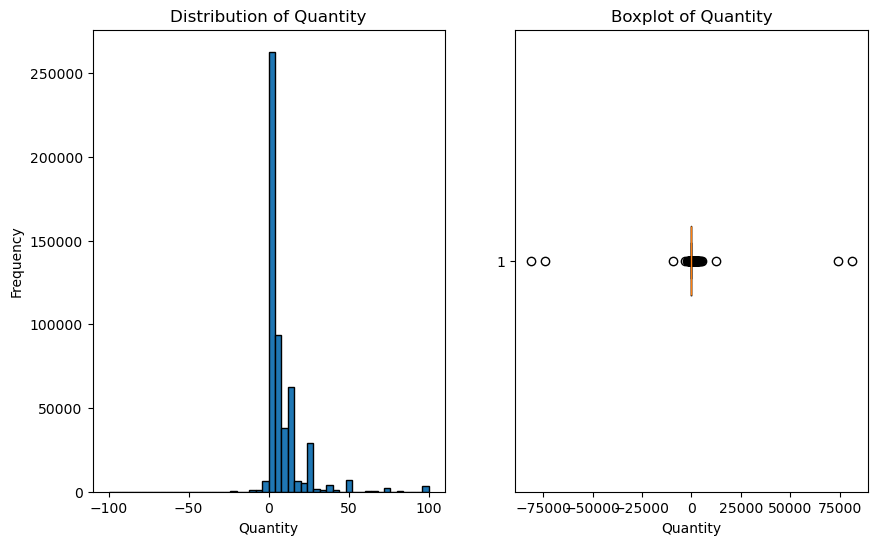

Mean of Quantity: 10.030653552647555
Median of Quantity: 3.0


In [19]:
#Now, lets see the distribution of the 'Quantity' column to decide how to handle the outliers
plot_column_distribution(df,'Quantity', 50, -100, 100, True)
#calculate the mean and median of the 'Quantity' column in the updated df
print(f'Mean of Quantity: {df["Quantity"].mean()}')
print(f'Median of Quantity: {df["Quantity"].median()}')

Outliers in the 'Quantity' column using the IQR method

In [20]:

# Handling outliers in the 'Quantity' column
#Inspecting the data

# Seems like the distribution of the 'Quantity' column is right-skewed, with a long tail on the right side. 
# The meadian value of the 'Quantity' column is around 3, while the mean value is around 10, 
# which indicates that there are some extreme values in the 'Quantity' column that are pulling the mean value to the right. 
# The boxplot also shows that there are some outliers in the 'Quantity' column, with values greater than 100.

#Let's see how many rows have a 'Quantity' value greater than 100
print(f'Number of rows with Quantity greater than 100: {len(df[df['Quantity'] > 100])}')
#Result: Number of rows with Quantity greater than 100: 4948



Number of rows with Quantity greater than 100: 4948


In [21]:
#Ideally, we would like to keep all the data in the 'Quantity' column, since it is an important variable for our analysis.
#for invoices that have been cancelled, we will find both the invoice number and its associated cancelled invoice number 
# ie. if we have an invoice number 536370 and a cancelled invoice number C536370, we will find both of them and analyze the quantity 
# and unit price of the items in these invoices to see if they match and if there are any discrepancies that we need to handle 
# (e.g. if the quantity in the cancelled invoice is greater than the quantity in the original invoice, 
# we might need to investigate further to see if there was a mistake in the cancellation process 
# or if there was a return of items that were not properly recorded, etc.)
# So let's confrm if all the cancelled invoices have a corresponding original invoice with the same StockCode, Description, UnitPrice, CustomerID, Country and InvoiceDate but with a positive quantity (since cancelled invoices have negative quantities)

# NOTE: This code is taking some time to run since we have to loop through all the cancelled invoices and find their corresponding original invoices, 
# which can be time-consuming if we have a large number of cancelled invoices. 
# WE can optimize this code by using merge or join operations instead of looping through the cancelled invoices, which can significantly reduce the execution time (Acording to Copilot).
# We are dopping this for now.

'''
df_cancelled_invoices = df[df['Cancelled'] == True]
for invoice in df_cancelled_invoices['InvoiceNo']:
    original_invoice = invoice.replace('C', '')
    cancelled_invoice = invoice
    original_invoice_data = df[(df['InvoiceNo'] == original_invoice) & (df['Cancelled'] == False)]
    cancelled_invoice_data = df[df['InvoiceNo'] == cancelled_invoice]
    if not original_invoice_data.empty and not cancelled_invoice_data.empty:
        for index, row in cancelled_invoice_data.iterrows():
            stock_code = row['StockCode']
            description = row['Description']
            unit_price = row['UnitPrice']
            customer_id = row['CustomerID']
            country = row['Country']
            invoice_date = row['InvoiceDate']
            quantity_cancelled = row['Quantity']
            original_row = original_invoice_data[(original_invoice_data['StockCode'] == stock_code) &
                                                 (original_invoice_data['Description'] == description) &
                                                 (original_invoice_data['UnitPrice'] == unit_price) &
                                                 (original_invoice_data['CustomerID'] == customer_id) &
                                                 (original_invoice_data['Country'] == country) &
                                                 (original_invoice_data['InvoiceDate'] == invoice_date)]
            if not original_row.empty:
                quantity_original = original_row.iloc[0]['Quantity']
                if quantity_cancelled != -quantity_original:
                    print(f'Discrepancy found in invoice {invoice}: Cancelled quantity {quantity_cancelled} does not match original quantity {-quantity_original}')
            else:
                print(f'No matching original invoice found for cancelled invoice {invoice}')
    


'''


"\ndf_cancelled_invoices = df[df['Cancelled'] == True]\nfor invoice in df_cancelled_invoices['InvoiceNo']:\n    original_invoice = invoice.replace('C', '')\n    cancelled_invoice = invoice\n    original_invoice_data = df[(df['InvoiceNo'] == original_invoice) & (df['Cancelled'] == False)]\n    cancelled_invoice_data = df[df['InvoiceNo'] == cancelled_invoice]\n    if not original_invoice_data.empty and not cancelled_invoice_data.empty:\n        for index, row in cancelled_invoice_data.iterrows():\n            stock_code = row['StockCode']\n            description = row['Description']\n            unit_price = row['UnitPrice']\n            customer_id = row['CustomerID']\n            country = row['Country']\n            invoice_date = row['InvoiceDate']\n            quantity_cancelled = row['Quantity']\n            original_row = original_invoice_data[(original_invoice_data['StockCode'] == stock_code) &\n                                                 (original_invoice_data['Description

In [22]:
#Detecting Outliers in the 'Quantity' column using the IQR method

#NOTE: We are not using the Z-score method to handle outliers in the 'Quantity' column since it is not suitable for right-skewed distributions with a long tail, as is the case with our 'Quantity' column.
# since the Quantity column is right-skewed, we will have a lot of outliers using the IQR method 
# to handle outliers in the 'Quantity' column, since it is more suitable for right-skewed distributions with a long tail.

Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)
print(f'Q1: {Q1}, Q3: {Q3}')
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f'Lower bound: {lower_bound}, Upper bound: {upper_bound}')
outliers = df[(df['Quantity'] < lower_bound) | (df['Quantity'] > upper_bound)]
print(f'Number of outliers in the Quantity column using IQR method: {len(outliers)}')

Q1: 1.0, Q3: 10.0
Lower bound: -12.5, Upper bound: 23.5
Number of outliers in the Quantity column using IQR method: 57598


99th percentile value of Quantity: 100.0


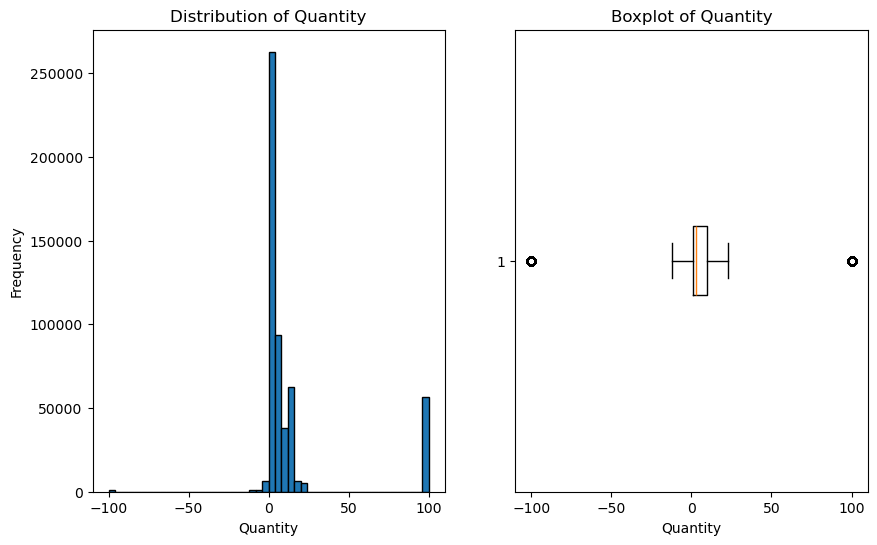

"\nfor invoice in df_cancelled_invoices['InvoiceNo']:\n    original_invoice = invoice.replace('C', '')\n    cancelled_invoice = invoice\n    original_invoice_data = df[(df['InvoiceNo'] == original_invoice) & (df['Cancelled'] == False)]\n    cancelled_invoice_data = df[df['InvoiceNo'] == cancelled_invoice]\n    if not original_invoice_data.empty and not cancelled_invoice_data.empty:\n        for index, row in cancelled_invoice_data.iterrows():\n            stock_code = row['StockCode']\n            description = row['Description']\n            unit_price = row['UnitPrice']\n            customer_id = row['CustomerID']\n            country = row['Country']\n            invoice_date = row['InvoiceDate']\n            quantity_cancelled = row['Quantity']\n            original_row = original_invoice_data[(original_invoice_data['StockCode'] == stock_code) &\n                                                 (original_invoice_data['Description'] == description) &\n                               

In [23]:
# Action: we will replace the outliers by setting values above the 95th percentile to the 99th percentile value
# and negative that value for cancelled invoices, since cancelled invoices have negative quantities and represent returns, 
# which can be considered as a loss of revenue for the company.

p99_quantity = df['Quantity'].quantile(0.99)
print(f'99th percentile value of Quantity: {p99_quantity}')

df['Quantity'] = np.where((df['Quantity'] < lower_bound) | (df['Quantity'] > upper_bound) & (df['Cancelled'] == False), p99_quantity, df['Quantity'])
df['Quantity'] = np.where((df['Quantity'] < lower_bound) | (df['Quantity'] > upper_bound) & (df['Cancelled'] == True), p99_quantity *-1, df['Quantity'])

#plotting the distribution of the 'Quantity' column after handling outliers
plot_column_distribution(df,'Quantity', 50, -100, 100, True)

#NOTE: this may result in some discrepancies in the quantities ordered andreturned vetween the original and cancelled invoices, since we are replacing extreme values with the median value, which can affect the overall distribution of the 'Quantity' column and the total revenue calculated from it.
#We would like to ensure that cancelled invoices and corresponding original invoices have matching quantities (with opposite signs) to maintain the integrity of our revenue analysis, 
#but the code takes so much time to run. We will ignore it for now.

'''
for invoice in df_cancelled_invoices['InvoiceNo']:
    original_invoice = invoice.replace('C', '')
    cancelled_invoice = invoice
    original_invoice_data = df[(df['InvoiceNo'] == original_invoice) & (df['Cancelled'] == False)]
    cancelled_invoice_data = df[df['InvoiceNo'] == cancelled_invoice]
    if not original_invoice_data.empty and not cancelled_invoice_data.empty:
        for index, row in cancelled_invoice_data.iterrows():
            stock_code = row['StockCode']
            description = row['Description']
            unit_price = row['UnitPrice']
            customer_id = row['CustomerID']
            country = row['Country']
            invoice_date = row['InvoiceDate']
            quantity_cancelled = row['Quantity']
            original_row = original_invoice_data[(original_invoice_data['StockCode'] == stock_code) &
                                                 (original_invoice_data['Description'] == description) &
                                                 (original_invoice_data['UnitPrice'] == unit_price) &
                                                 (original_invoice_data['CustomerID'] == customer_id) &
                                                 (original_invoice_data['Country'] == country) &
                                                 (original_invoice_data['InvoiceDate'] == invoice_date)]
            if not original_row.empty:
                quantity_original = original_row.iloc[0]['Quantity']
                if quantity_cancelled != -quantity_original:
                    print(f'Discrepancy found in invoice {invoice}: Cancelled quantity {quantity_cancelled} does not match original quantity {-quantity_original}')
                    if quantity_cancelled == -median_quantity:
                        df.loc[df['InvoiceNo'] == cancelled_invoice, 'Quantity'] = -quantity_original
                    else:
                        if quantity_original == median_quantity:
                            df.loc[df['InvoiceNo'] == original_invoice, 'Quantity'] = quantity_cancelled*-1
                        
            else:
                print(f'No matching original invoice found for cancelled invoice {invoice}')
'''


#### Unit Price Column

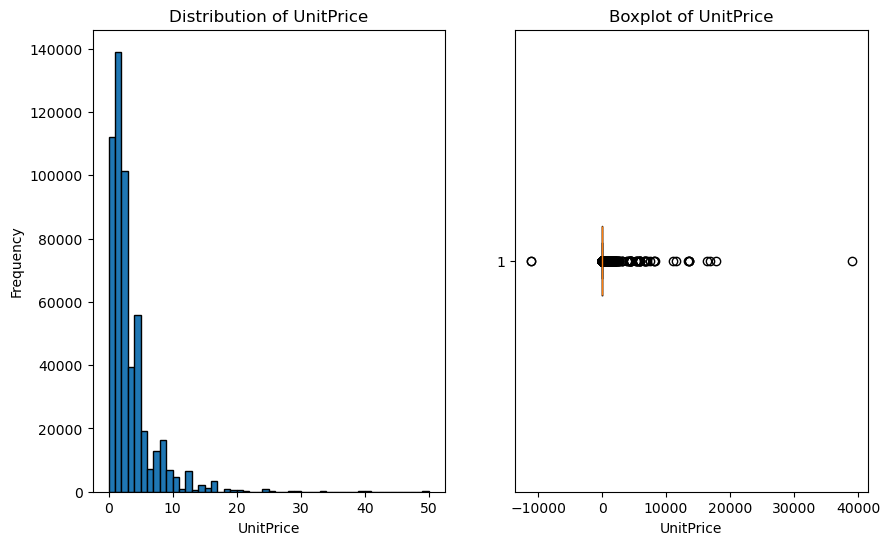

In [24]:
# plotting the distribution
plot_column_distribution(df,'UnitPrice', 50, 0, 50, True)

In [25]:
#let's obseve entries that have negative unit price values to confirm that they are indeed outliers and not valid entries that we should keep for our analysis (e.g. returns, discounts, etc.)
print(df[df['UnitPrice'] < 0].head())

#let's find the description of the entries that have negative unit price values to see if they are indeed outliers and not valid entries that we should keep for our analysis (e.g. returns, discounts, etc.)
print(df[df['UnitPrice'] < 0]['Description'].unique())
#Result:['Adjust bad debt']

#Seems like all the entries with negative unit price values are related to bad debt adjustments, 
#which are not valid entries that we should keep for our analysis, since they do not represent actual sales transactions and can skew our revenue analysis.
# We can safley exclude these entries from the dataframe 
# (we can keep them in a separate dataframe for further analysis if needed)

#Creating a new dataframe for bad debt adjustments
df_bad_debt_adjustments = df[df['UnitPrice'] < 0]
print(f'Number of bad debt adjustments (UnitPrice < 0): {len(df_bad_debt_adjustments)}')

#exporting the bad debt adjustments to a new csv file and putting it in the silver layer for further analysis
df_bad_debt_adjustments.to_csv('../data/silver/bad_debt_adjustments.csv', index=False)

#Updating the original dataframe by removing the bad debt adjustments (in case Danny did not remove them in the previous steps)
df = df[df['UnitPrice'] >= 0]
print(f'Number of rows after removing bad debt adjustments: {len(df)}')


         index InvoiceNo StockCode      Description  Quantity  \
299983  299983   A563186         B  Adjust bad debt       1.0   
299984  299984   A563187         B  Adjust bad debt       1.0   

               InvoiceDate  UnitPrice  CustomerID         Country  Cancelled  
299983 2011-08-12 14:51:00  -11062.06        <NA>  United Kingdom      False  
299984 2011-08-12 14:52:00  -11062.06        <NA>  United Kingdom      False  
['Adjust bad debt']
Number of bad debt adjustments (UnitPrice < 0): 2
Number of rows after removing bad debt adjustments: 535303


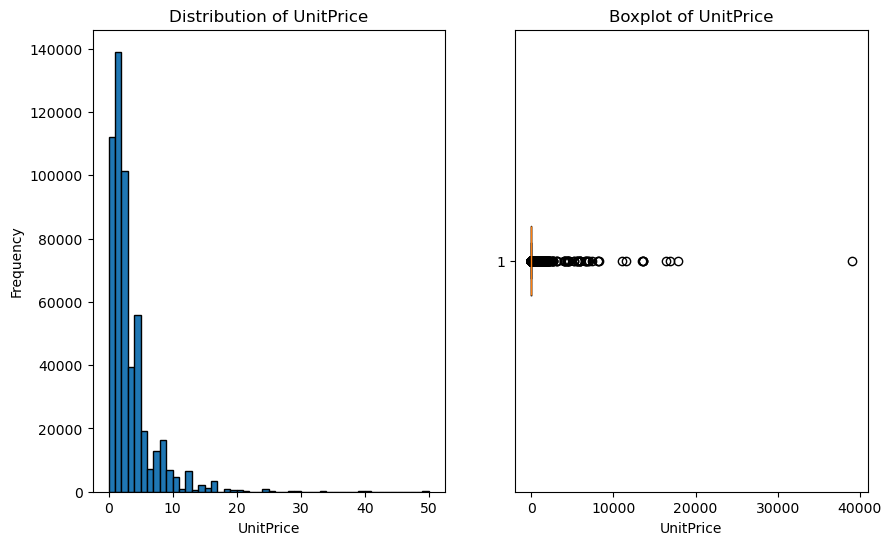

In [26]:
#observing the distribution of the 'UnitPrice' column after removing bad debt adjustments
plot_column_distribution(df,'UnitPrice', 50, 0, 50, True)

Outliers in the 'UnitPrice' column using the IQR method

In [27]:
#Detecting Outliers in the 'UnitPrice' column using the IQR method
Q1 = df['UnitPrice'].quantile(0.25)
Q3 = df['UnitPrice'].quantile(0.75)
print(f'Q1: {Q1}, Q3: {Q3}')

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f'Lower bound: {lower_bound}, Upper bound: {upper_bound}')

outliers_unit_price = df[(df['UnitPrice'] < lower_bound) | (df['UnitPrice'] > upper_bound)]
print(f'Number of outliers in the UnitPrice column using IQR method: {len(outliers_unit_price)}')   



Q1: 1.25, Q3: 4.13
Lower bound: -3.0700000000000003, Upper bound: 8.45
Number of outliers in the UnitPrice column using IQR method: 39448


In [28]:
# Action: we can replace the outliers  by setting values above the 99th percentile to the 99th percentile value 

unit_price_99th_percentile = df['UnitPrice'].quantile(0.99)
# Result:unit_price_99th_percentile = 18.0
df['UnitPrice'] = np.where(df['UnitPrice'] > unit_price_99th_percentile, unit_price_99th_percentile, df['UnitPrice'])

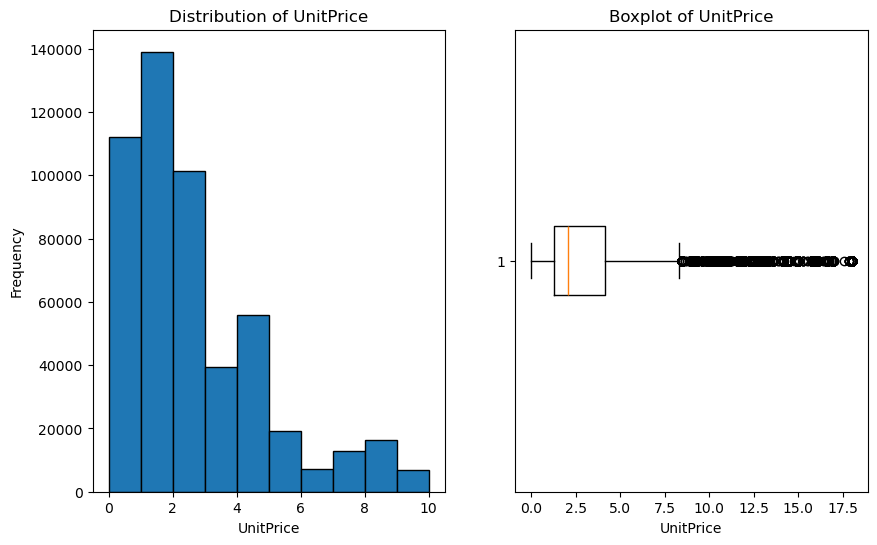

In [29]:
#observing the distribution of the 'UnitPrice' column after handling outliers
plot_column_distribution(df,'UnitPrice', 10, 0, 10, True)

### 2. Removing Missing/Invalid Customer IDs (Danny)

By mistake I worked on this task!
I noticed ananymous transaction and decided to keep the orginal dataframe `df` as is, and create 2 other dataframes t export a csv and use as needed.
- The orginal dataframe `df` will allow us to perform transaction/sales-level analysis on all data (overall sales volume, average basket value, product-level demand, etc).
- The other two dataframes will allow us to split the data into: 
    - `df_known_customers`: rows with a valid CustomerID. This dataset will serve to perform customer-level analysis (customer behavior, customer segmentation, customer retention, etc.)
    - `df_anonymous_transactions`: rows with missing CustomerID. If needed, this may help separately analyze anonymous transactions as a separate segment.

In [30]:
nb_customers = df['CustomerID'].nunique()
print(f'The number of unique customers is: {nb_customers}')

The number of unique customers is: 4372


In [31]:
df_customerIDs_list = df['CustomerID'].unique().tolist()
print(f'The list of unique customer IDs is:\n {df_customerIDs_list}')

The list of unique customer IDs is:
 [17850, 13047, 12583, 13748, 15100, 15291, 14688, 17809, 15311, 14527, 16098, 18074, 17420, 16029, 16250, 12431, 17511, 17548, 13705, 13747, 13408, 13767, 17924, 13448, 15862, 15513, 12791, 16218, 14045, 14307, 17908, 17920, <NA>, 12838, 13255, 16583, 18085, 13758, 13694, 15983, 14849, 17968, 16210, 17897, 17377, 16552, 17181, 17951, 14729, 12748, 15012, 12868, 17572, 14078, 14001, 12662, 15525, 14237, 17905, 15485, 12433, 16955, 15350, 15605, 18144, 15922, 14594, 15165, 14911, 16456, 17841, 12472, 17346, 17643, 17873, 13093, 12921, 13468, 17760, 16928, 16048, 16274, 14496, 14696, 16539, 17025, 13777, 17690, 12947, 17460, 18229, 14142, 17069, 13065, 14606, 16835, 15235, 13576, 18011, 13090, 15694, 14741, 13715, 14092, 17732, 12855, 15752, 17855, 14047, 17925, 13941, 17017, 14135, 13108, 12471, 15601, 13418, 14766, 15658, 14388, 14901, 18041, 15955, 15070, 16244, 15111, 14390, 16546, 15260, 13305, 14491, 14060, 15923, 16752, 17287, 15363, 12915, 1554

In [32]:
df_known_customers = df[df['CustomerID'].notnull()]
print(f'The number of transactions with known customers is: {len(df_known_customers)}')
df_known_customers.info()

The number of transactions with known customers is: 401604
<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   index        401604 non-null  int64         
 1   InvoiceNo    401604 non-null  object        
 2   StockCode    401604 non-null  object        
 3   Description  401604 non-null  object        
 4   Quantity     401604 non-null  float64       
 5   InvoiceDate  401604 non-null  datetime64[ns]
 6   UnitPrice    401604 non-null  float64       
 7   CustomerID   401604 non-null  Int64         
 8   Country      401604 non-null  object        
 9   Cancelled    401604 non-null  bool          
dtypes: Int64(1), bool(1), datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 31.4+ MB


In [33]:
#exporting df_known_customers to a new csv file and putting it in the silver layer for further analysis
df_known_customers.to_csv('../data/silver/known_customers.csv', index=False)

In [34]:
df_anonymous_transactions = df[df['CustomerID'].isnull()]
print(f'The number of transactions with unknown customers is: {len(df_anonymous_transactions)}')
df_anonymous_transactions.info()


The number of transactions with unknown customers is: 133699
<class 'pandas.core.frame.DataFrame'>
Index: 133699 entries, 622 to 541540
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   index        133699 non-null  int64         
 1   InvoiceNo    133699 non-null  object        
 2   StockCode    133699 non-null  object        
 3   Description  133107 non-null  object        
 4   Quantity     133699 non-null  float64       
 5   InvoiceDate  133699 non-null  datetime64[ns]
 6   UnitPrice    133699 non-null  float64       
 7   CustomerID   0 non-null       Int64         
 8   Country      133699 non-null  object        
 9   Cancelled    133699 non-null  bool          
dtypes: Int64(1), bool(1), datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 10.5+ MB


In [35]:
#exporting df_anonymous_transactions to a new csv file and putting it in the silver layer for further analysis
df_anonymous_transactions.to_csv('../data/silver/anonymous_transactions.csv', index=False)

### Export the clean dataset in "Silver” Folder

In [36]:
#Exporting the clean dataset in "Silver" Folder
df.to_csv('../data/silver/online_retail_cleaned.csv', index=False)